<a href="https://colab.research.google.com/github/late-cat/Sec_colab/blob/main/Untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Customer Churn Prediction

In this notebook, I built a customer churn prediction model using two approaches: Random Forest and an Artificial Neural Network (ANN). I first loaded and preprocessed the data (including feature engineering and scaling), then trained both models. Finally, I compared their performance using different metrics to see which one works better for predicting customer churn.

In [48]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
##loading dataset(it's from kaggle)
dataset=pd.read_csv("https://raw.githubusercontent.com/late-cat/Sec_colab/main/data/Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## dividing the data set into dependent and independent features

In [51]:
X=dataset.iloc[:,3:13]
Y=dataset.iloc[:,13]


In [52]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [53]:
Y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


##Feature engeneering

In [54]:
geography=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)

In [55]:
##concatanate into the data frame
X=X.drop(['Geography','Gender'],axis=1)

In [56]:
X=pd.concat([X,geography,gender],axis=1)

In [57]:
##splitting dataset into test train
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [58]:
##fetaure scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [59]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [60]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [61]:
##within train set
X_train.shape

(8000, 11)

In [62]:
## First ML model: RF
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,random_state=0)
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=0)

In [63]:
Y_predict_rf=rf_model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix
cm_rf = confusion_matrix(Y_test, Y_predict_rf)
score_rf = accuracy_score(Y_test, Y_predict_rf)

In [65]:
print("RF accuracy is:\n",score_rf)

'''format for CM: [TN FP]
                  [FN TP]'''

print("RF CM is:\n",cm_rf)

RF accuracy is:
 0.867
RF CM is:
 [[1523   72]
 [ 194  211]]


In [66]:
## constructing ANN (the second ML Model)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [67]:
from tensorflow.keras.layers import Input
classifier = Sequential()
classifier.add(Input(shape=(11,)))

In [68]:
##adding the inp layer
classifier.add(Dense(units=11, activation='relu'))

In [69]:
##adding the first hidden layer
classifier.add(Dense(units=7, activation='relu'))

In [70]:
##adding 2nd HL
classifier.add(Dense(units=6, activation='relu'))

In [71]:
## adding O/P layer (it's a binary classfication so sigmoid actv func)
classifier.add(Dense(1, activation='sigmoid'))

In [72]:
##compile the model
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [73]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [74]:
##early stopping
import tensorflow as tf
from tensorflow import keras
early_stopping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [75]:
 #Compiling
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Early Stopping callback
model_history = classifier.fit(
    X_train,
    Y_train.values,
    validation_split=0.33,
    batch_size=10,
    epochs=1000,
    callbacks=[early_stopping]
)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7970 - loss: 0.4809 - val_accuracy: 0.7993 - val_loss: 0.4529
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8179 - loss: 0.4284 - val_accuracy: 0.7967 - val_loss: 0.4394
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8199 - loss: 0.4183 - val_accuracy: 0.8042 - val_loss: 0.4312
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8233 - loss: 0.4096 - val_accuracy: 0.8046 - val_loss: 0.4273
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8238 - loss: 0.4026 - val_accuracy: 0.8198 - val_loss: 0.4175
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8319 - loss: 0.3940 - val_accuracy: 0.8160 - val_loss: 0.4119
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8388 - loss: 0.3837 - val_accuracy: 0.8281 - val_loss: 0.3998
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8438 - loss: 0.3755 - 

In [76]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

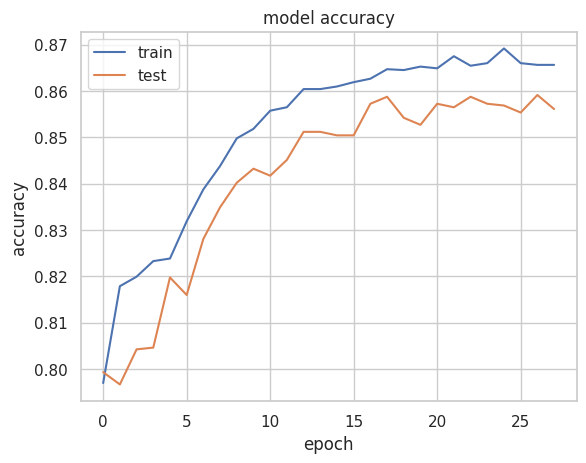

In [77]:
# summarize history for accuracy
import matplotlib.pyplot as plt

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

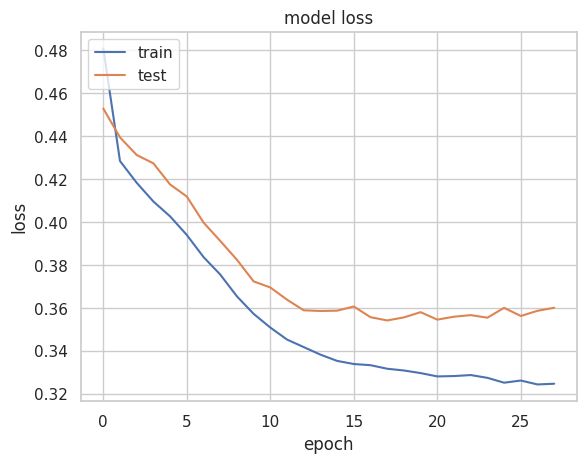

In [78]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [79]:
##predict the test set results
Y_predict=classifier.predict(X_test)
Y_predict=(Y_predict>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [80]:
##calc the accuracy
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_predict)

In [81]:
from sklearn.metrics import accuracy_score
score = accuracy_score(Y_test, Y_predict)

In [82]:
## accuracy of the ANN
score

0.8585

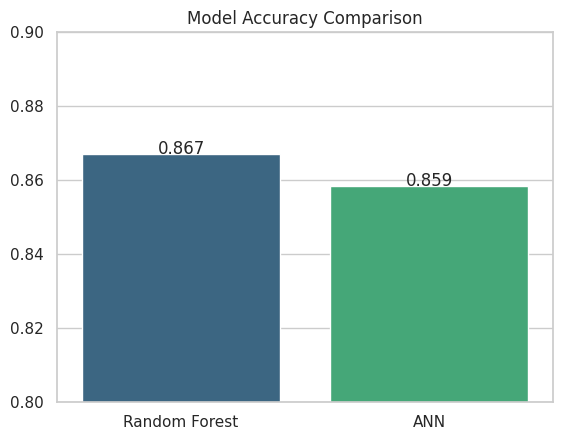

In [87]:
## comparing the accuracy b/w the ANN and RF
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

acc = [score_rf, score]
sns.barplot(x=['Random Forest', 'ANN'], y=acc, hue=['Random Forest', 'ANN'], palette='viridis', legend=False)

plt.title('Model Accuracy Comparison'); plt.ylim(0.8, 0.9)
[plt.text(i, v, f'{v:.3f}', ha='center') for i, v in enumerate(acc)]

plt.show()

/tmp/ipykernel_11706/198814256.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Random Forest', 'ANN'], y=f1, palette='coolwarm')


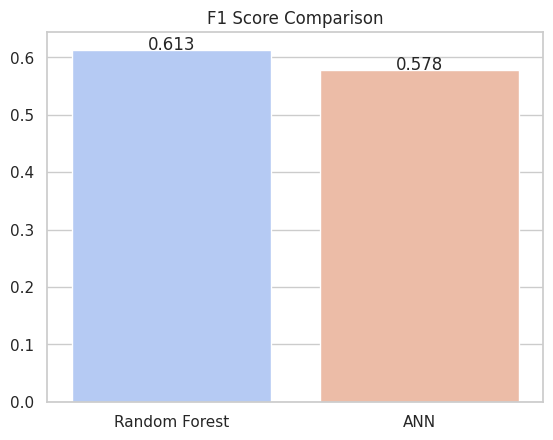

In [85]:
##F1 score comparision
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

f1 = [f1_rf, f1_ann]
sns.barplot(x=['Random Forest', 'ANN'], y=f1, palette='coolwarm')

plt.title('F1 Score Comparison')

for i, v in enumerate(f1):
    plt.text(i, v, f'{v:.3f}', ha='center')

plt.show()

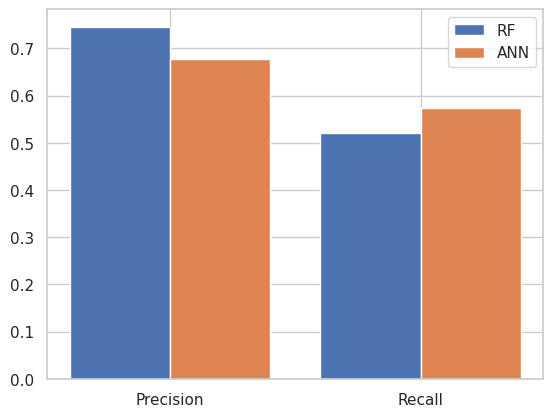

In [89]:
## Precision and Recall
'''
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
'''

from sklearn.metrics import precision_score, recall_score

# For Random Forest
precision_rf = precision_score(Y_test, Y_predict_rf, average='binary')
recall_rf = recall_score(Y_test, Y_predict_rf, average='binary')

# For ANN
precision_ann = precision_score(Y_test, Y_predict, average='binary')
recall_ann = recall_score(Y_test, Y_predict, average='binary')

labels = ['Precision', 'Recall']
rf = [precision_rf, recall_rf]
ann = [precision_ann, recall_ann]

x = range(len(labels))

plt.bar(x, rf, width=0.4, label='RF')
plt.bar([i+0.4 for i in x], ann, width=0.4, label='ANN')

plt.xticks([i+0.2 for i in x], labels)
plt.legend()
plt.show()

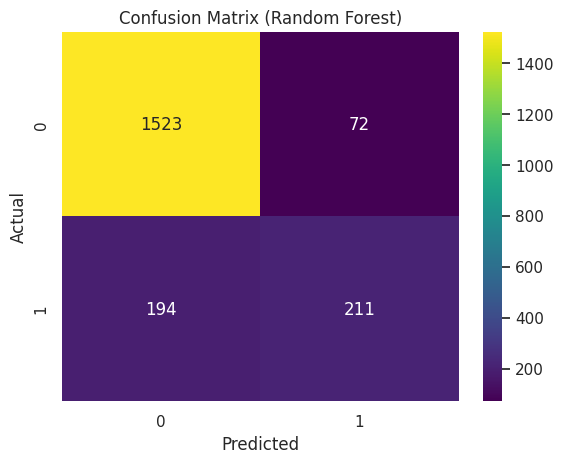

In [92]:
##confusion matrics(RF)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
'''
TN FP
FN TP
'''

cm = confusion_matrix(Y_test, Y_predict_rf)

sns.set_theme(style="whitegrid")
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')

plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [93]:
##saving
import pickle
classifier.save('model.keras')
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(sc, f)
print("Models and Scaler saved!")

Models and Scaler saved!
